# UK Jobs — Skills & Industry Analysis

**Source:** `data/UK_data/uk_jobs_final.csv`

### Sections
1. Dataset overview (categories, seniority, remote, education)
2. Job categories & title distribution
3. Hard skills — overall + by category
4. Most In-Demand & Most Essential Skills (cross-industry)
5. Hard skills — by seniority level
6. Soft skills — overall + by category
7. Category signature skills (>=55% concentration)
8. Skills co-occurrence heatmap
9. Location & remote trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

FINAL_CSV = 'data/UK_data/uk_jobs_final.csv'

df = pd.read_csv(FINAL_CSV, encoding='utf-8-sig', dtype={'job_id': str})
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print()
print('Categories:')
print(df['job_category'].value_counts().to_string())
df.head(3)

Loaded: 1,637 rows x 19 cols

Categories:
job_category
software-eng      749
data-science      306
devops            216
infrastructure    111
product           105
security          102
design             29
data-eng           19


,job_id,source,country,url,job_title,parsed_title,company,location,posted_date,seniority,min_years_exp,employment_type,remote_status,salary_min_annual,salary_max_annual,hard_skills,soft_skills,education,job_category
0,4314044699,LinkedIn,UK,https://www.linkedin.com/jobs/view/4314044699,Junior Software Engineer,Junior Software Engineer,Tripadvisor,"London, England, United Kingdom",2026-04-21,junior,NaN,full-time,hybrid,NaN,NaN,"Java, React, TypeScript, GraphQL, Kubernetes, SQL, NoSQL, AWS, C#, C++, obje...","versatility, collaboration, ownership, eagerness to learn",bachelor,software-eng
1,4402951771,LinkedIn,UK,https://www.linkedin.com/jobs/view/4402951771,Graduate Software Engineer,Graduate Software Engineer,Dexory,"Wallingford, England, United Kingdom",2026-04-16,junior,0.0,full-time,unknown,NaN,NaN,"Python, Git, Linux, C++, robotics, real-time systems, PyTorch, TensorFlow, c...","collaboration, problem-solving, growth mindset, architectural thinking, curi...",bachelor,software-eng
2,4379662791,LinkedIn,UK,https://www.linkedin.com/jobs/view/4379662791,"Software Engineer, New Grad","Software Engineer, New Grad",Deliveroo,"London, England, United Kingdom",2026-04-17,junior,0.0,full-time,unknown,NaN,NaN,"Go, Ruby, Python, Scala, Ruby on Rails, Rust, relational databases, PostgreS...","ownership, collaboration, problem-solving, technical curiosity, mentorship, ...",bachelor,software-eng


In [2]:
def parse_skills(series, lowercase=True):
    out = []
    for cell in series.dropna():
        for s in str(cell).split(','):
            s = s.strip().lower() if lowercase else s.strip()
            if s:
                out.append(s)
    return out

def top_n(series, n=20, lowercase=True):
    c = Counter(parse_skills(series, lowercase))
    return pd.Series({k: v for k, v in c.most_common(n)})

n_hard = len(parse_skills(df['hard_skills']))
n_soft = len(parse_skills(df['soft_skills']))
u_hard = len(set(parse_skills(df['hard_skills'])))
u_soft = len(set(parse_skills(df['soft_skills'])))
print(f'Hard skill mentions : {n_hard:,}  |  unique: {u_hard:,}')
print(f'Soft skill mentions : {n_soft:,}  |  unique: {u_soft:,}')
print(f'Avg hard skills/job : {n_hard/len(df):.1f}')
print(f'Avg soft skills/job : {n_soft/len(df):.1f}')

Hard skill mentions : 27,251  |  unique: 5,924
Soft skill mentions : 8,045  |  unique: 531
Avg hard skills/job : 16.6
Avg soft skills/job : 4.9


---
## 1. Dataset Overview

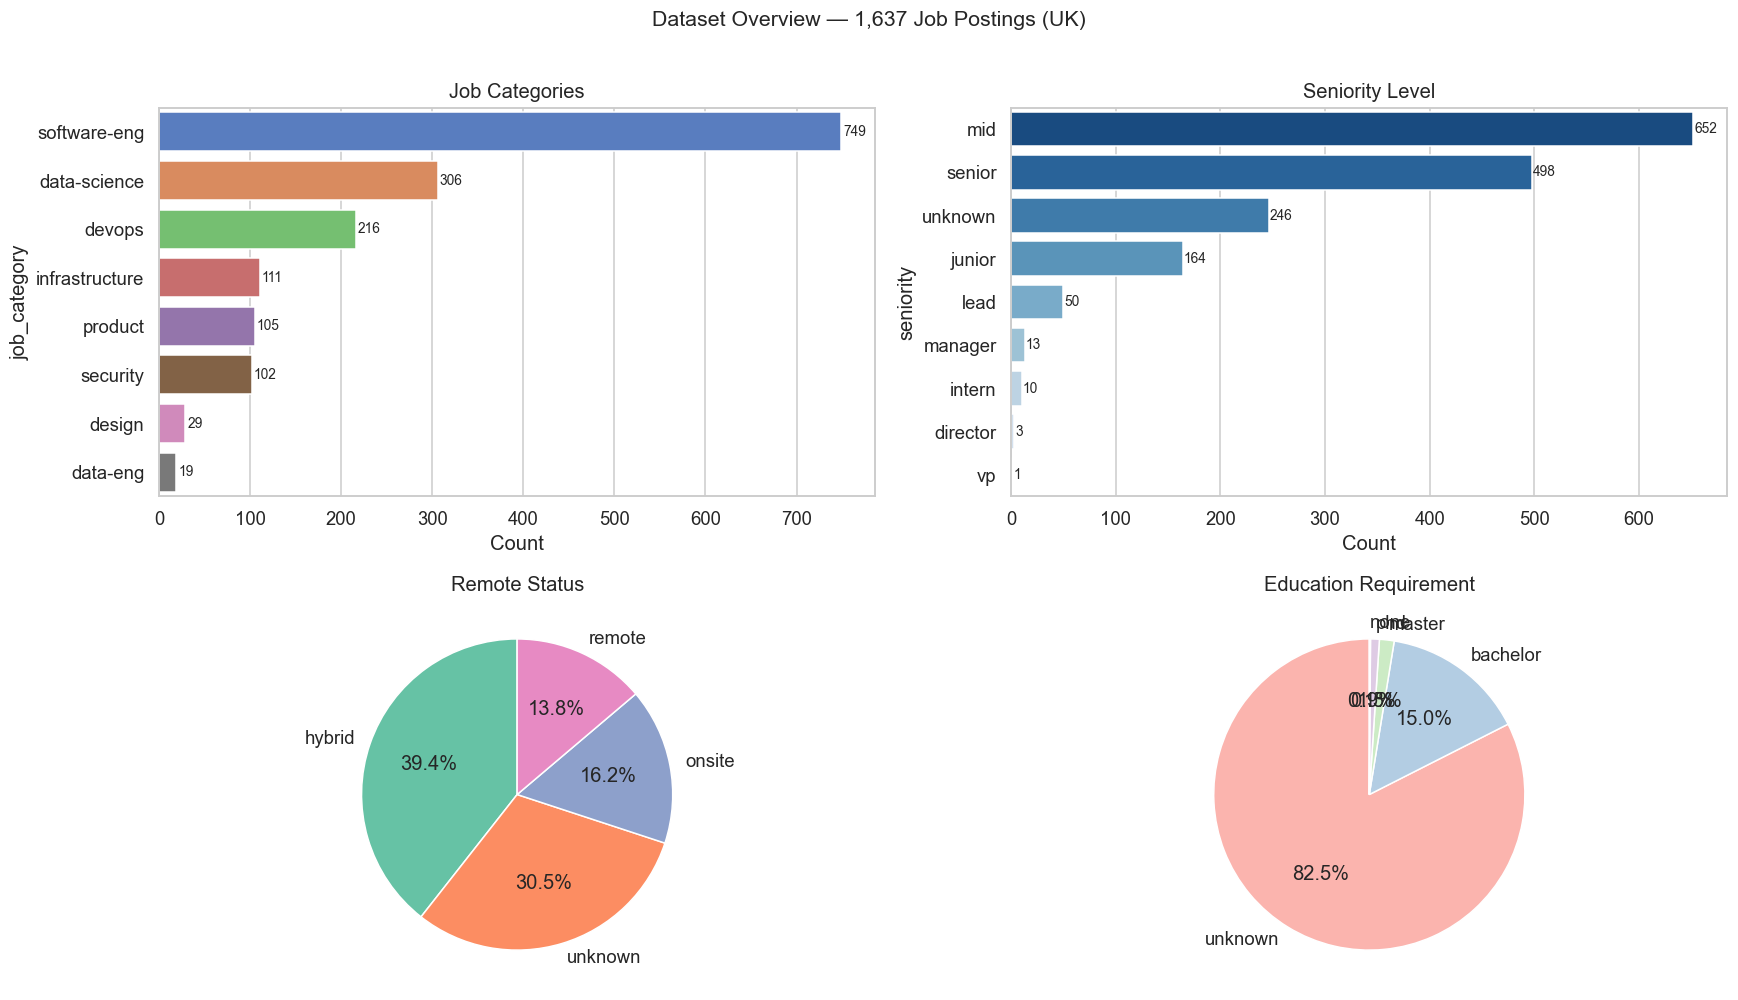

Total postings : 1,637
Date range     : 2026-04-04 -> 2026-05-04
Companies      : 987 unique


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

cat = df['job_category'].value_counts()
sns.barplot(x=cat.values, y=cat.index, ax=axes[0][0], palette='muted')
axes[0][0].set_title('Job Categories')
axes[0][0].set_xlabel('Count')
for p, v in zip(axes[0][0].patches, cat.values):
    axes[0][0].text(p.get_width() + 2, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=9)

sen = df['seniority'].value_counts()
sns.barplot(x=sen.values, y=sen.index, ax=axes[0][1], palette='Blues_r')
axes[0][1].set_title('Seniority Level')
axes[0][1].set_xlabel('Count')
for p, v in zip(axes[0][1].patches, sen.values):
    axes[0][1].text(p.get_width() + 1, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=9)

rem = df['remote_status'].value_counts()
axes[1][0].pie(rem.values, labels=rem.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set2', len(rem)), startangle=90)
axes[1][0].set_title('Remote Status')

edu = df['education'].value_counts()
axes[1][1].pie(edu.values, labels=edu.index, autopct='%1.1f%%',
               colors=sns.color_palette('Pastel1', len(edu)), startangle=90)
axes[1][1].set_title('Education Requirement')

plt.suptitle(f'Dataset Overview — {len(df):,} Job Postings (UK)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Total postings : {len(df):,}')
print(f'Date range     : {df["posted_date"].min()} -> {df["posted_date"].max()}')
print(f'Companies      : {df["company"].nunique():,} unique')

---
## 2. Job Titles & Category Distribution

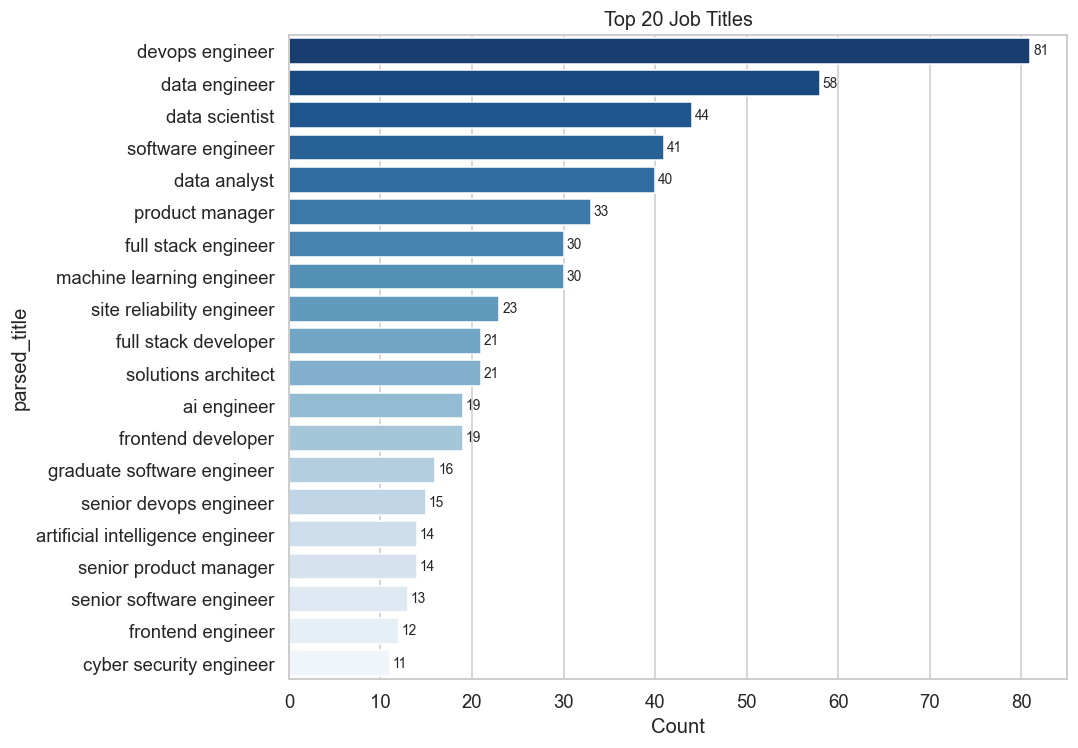

In [4]:
top_titles = df['parsed_title'].str.lower().str.strip().value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_titles.values, y=top_titles.index, ax=ax, palette='Blues_r')
ax.set_title('Top 20 Job Titles', fontsize=13)
ax.set_xlabel('Count')
for p, v in zip(ax.patches, top_titles.values):
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

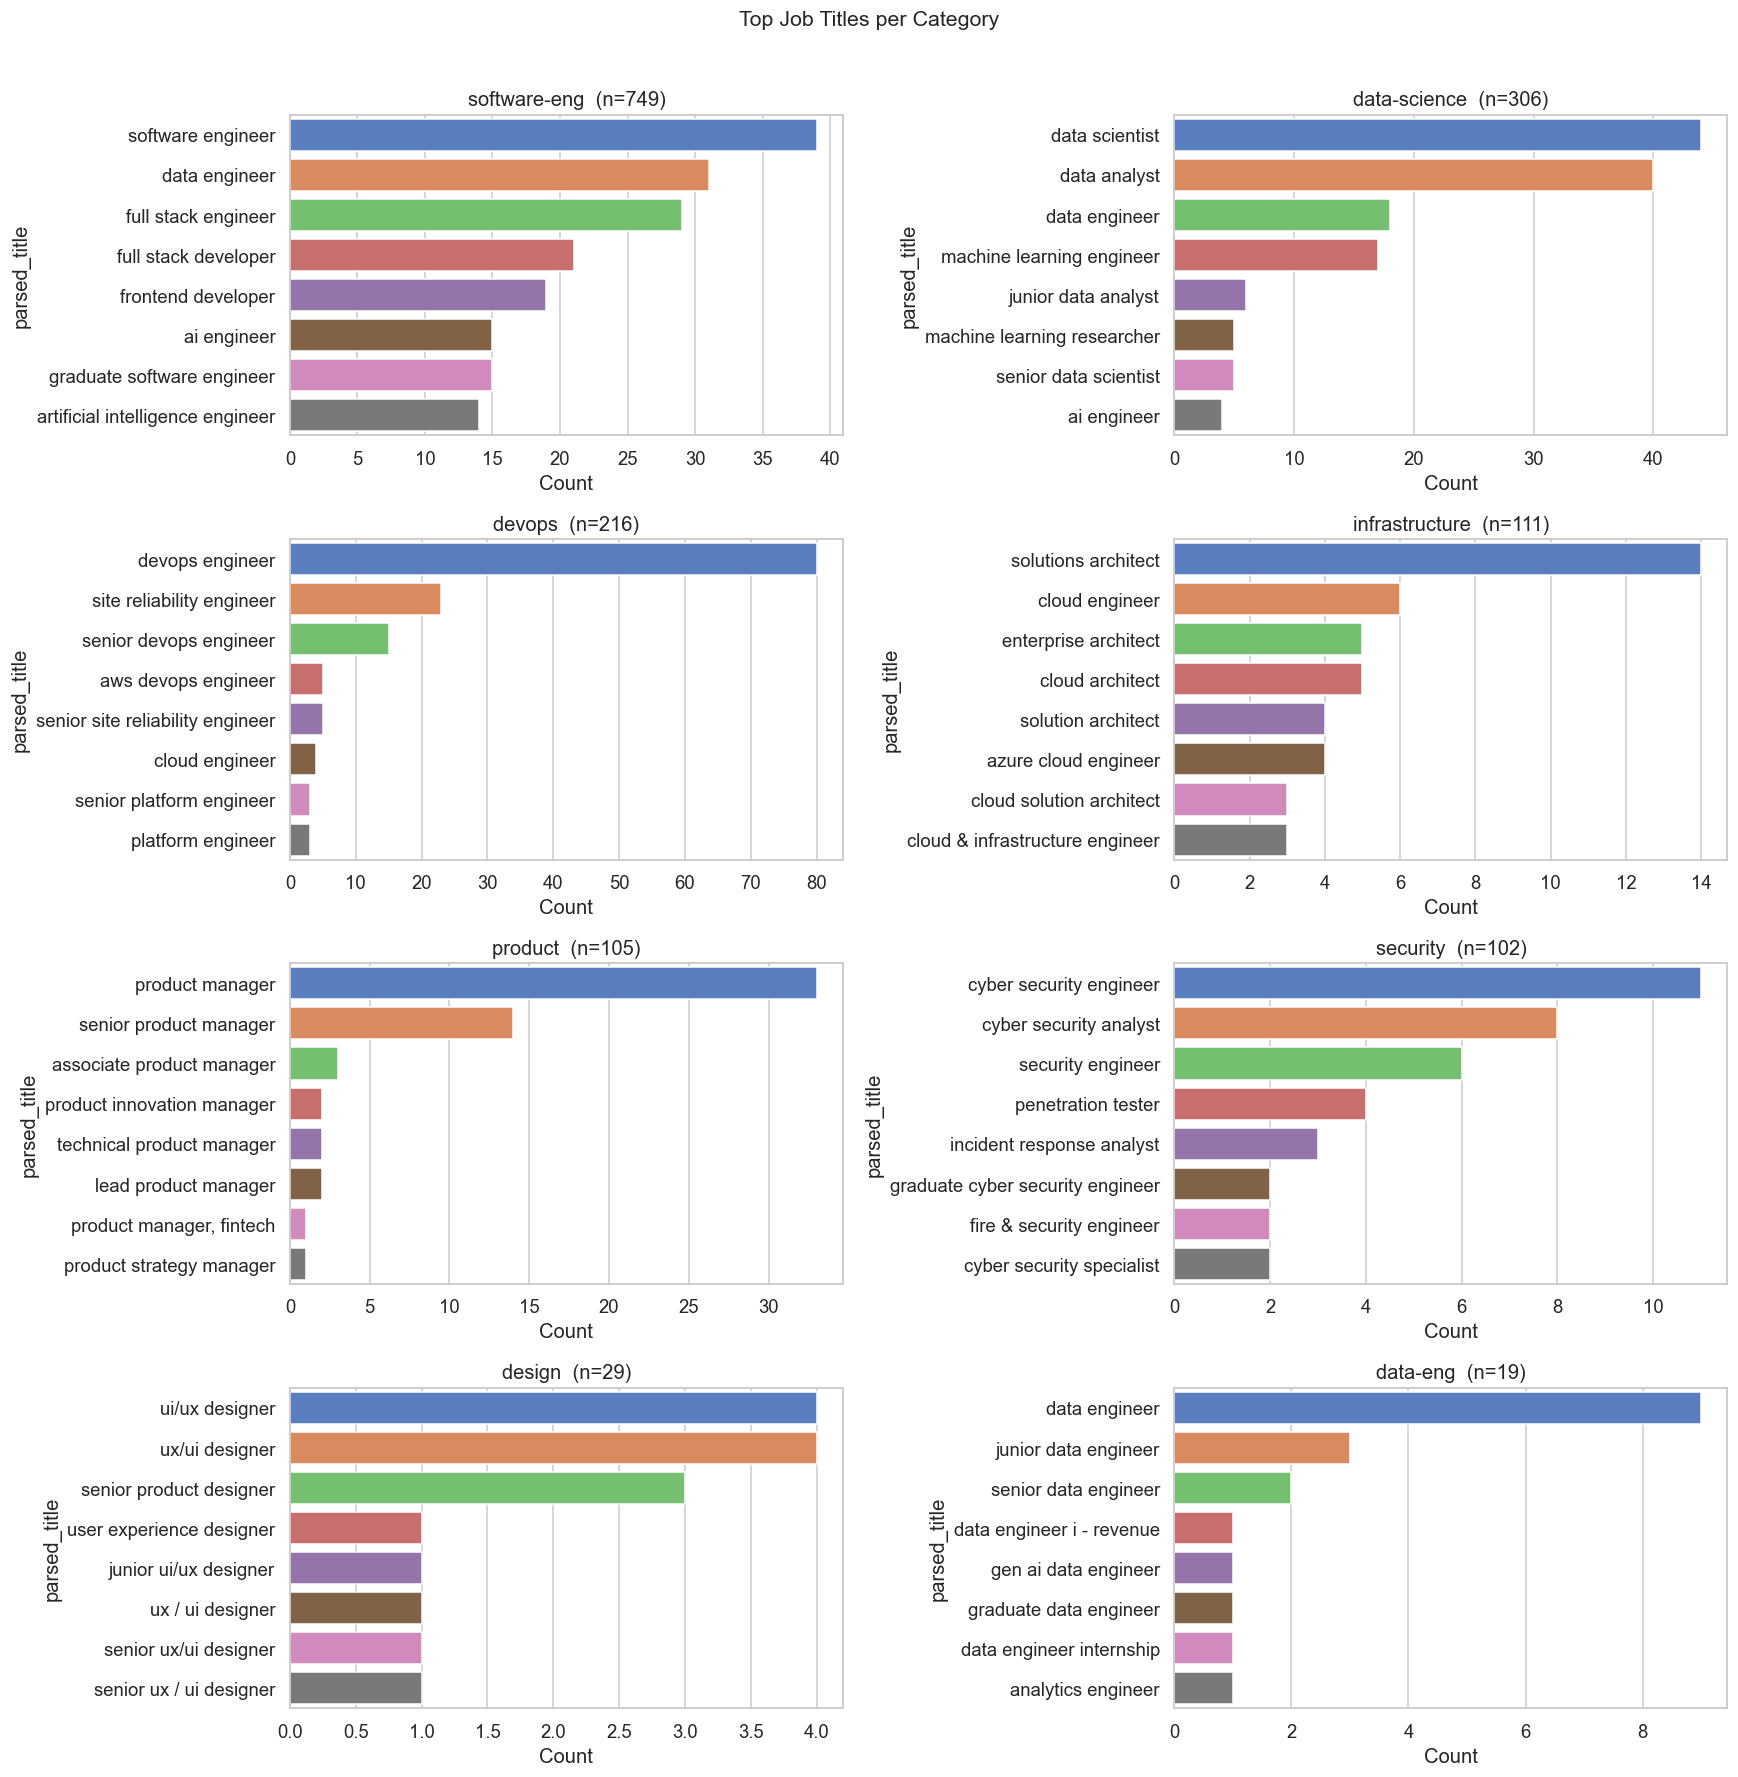

In [5]:
categories = df['job_category'].value_counts().index.tolist()
n_cols = 2
n_rows = -(-len(categories) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[df['job_category'] == cat]
    top = sub['parsed_title'].str.lower().str.strip().value_counts().head(8)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='muted')
    axes[i].set_title(f'{cat}  (n={len(sub):,})')
    axes[i].set_xlabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Job Titles per Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

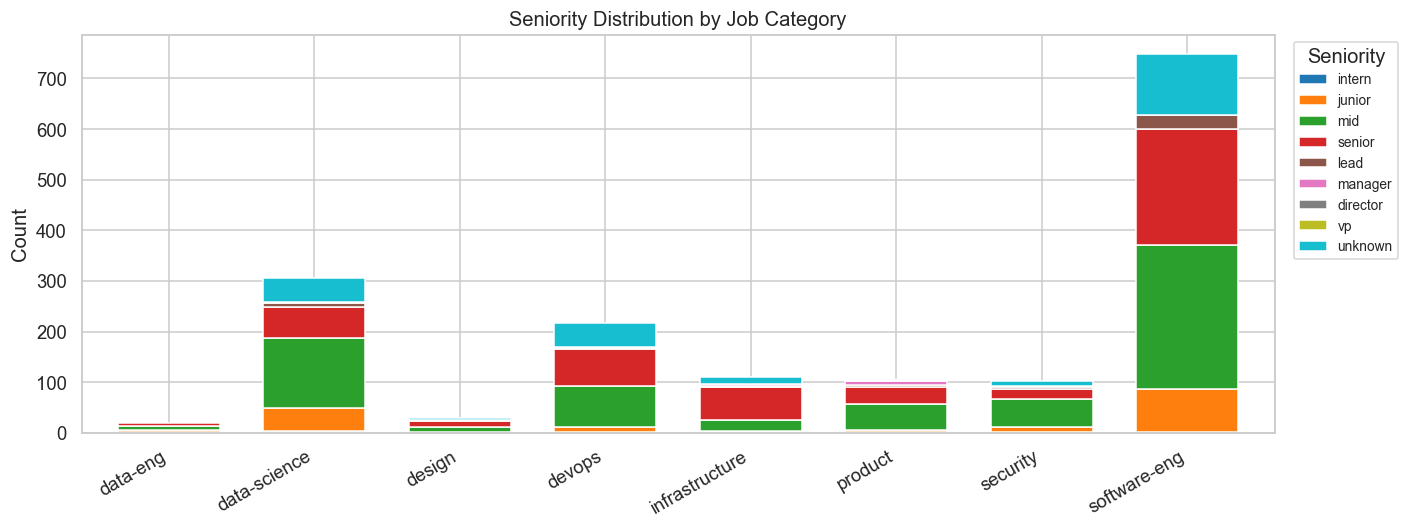

In [6]:
sen_order = ['intern', 'junior', 'mid', 'senior', 'lead', 'manager', 'director', 'vp', 'unknown']
sen_cat = df.groupby(['job_category', 'seniority']).size().unstack(fill_value=0)
sen_cat = sen_cat[[c for c in sen_order if c in sen_cat.columns]]

ax = sen_cat.plot(kind='bar', stacked=True, figsize=(13, 5), colormap='tab10', width=0.7)
ax.set_title('Seniority Distribution by Job Category')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.legend(title='Seniority', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Hard Skills — Overall

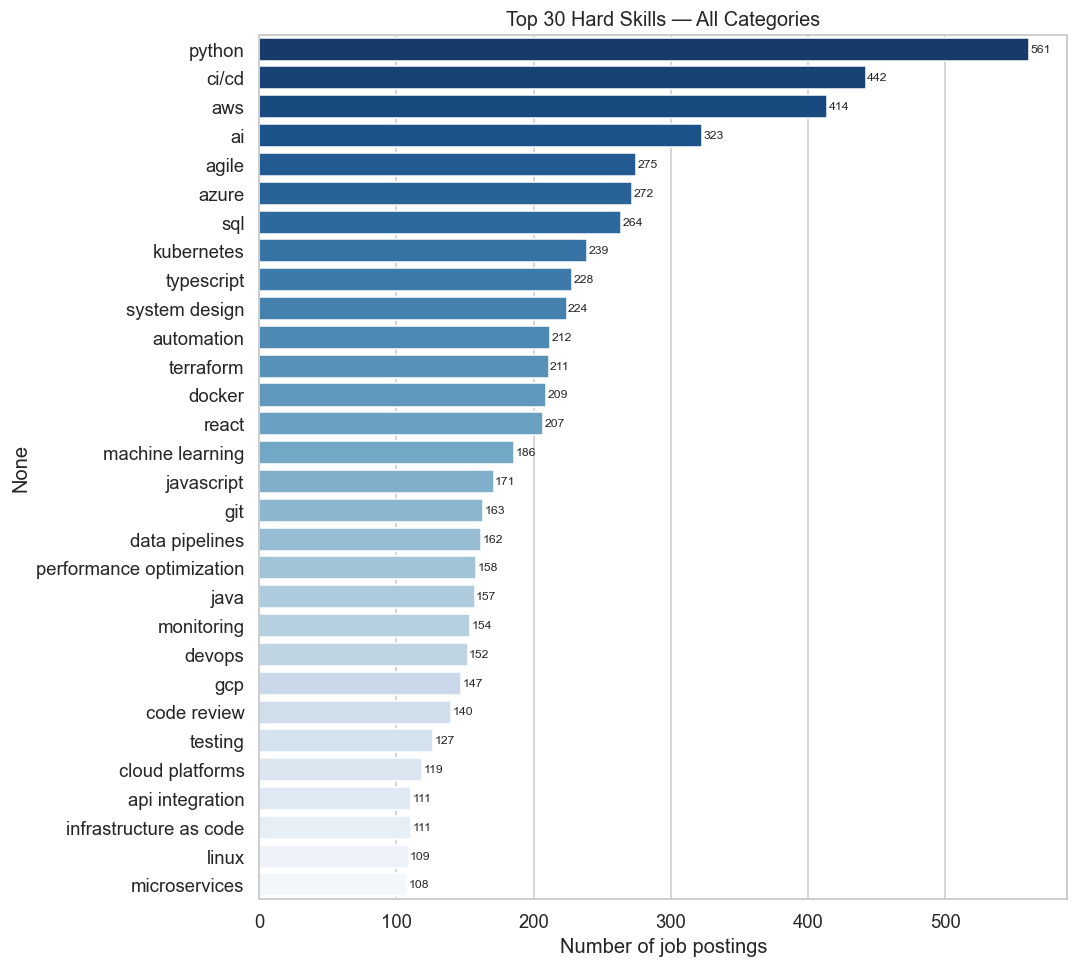

Top 30 Hard Skills with coverage:
  python                               561  (34.3%)
  ci/cd                                442  (27.0%)
  aws                                  414  (25.3%)
  ai                                   323  (19.7%)
  agile                                275  (16.8%)
  azure                                272  (16.6%)
  sql                                  264  (16.1%)
  kubernetes                           239  (14.6%)
  typescript                           228  (13.9%)
  system design                        224  (13.7%)
  automation                           212  (13.0%)
  terraform                            211  (12.9%)
  docker                               209  (12.8%)
  react                                207  (12.6%)
  machine learning                     186  (11.4%)
  javascript                           171  (10.4%)
  git                                  163  (10.0%)
  data pipelines                       162  (9.9%)
  performance optimization     

In [7]:
hard_top30 = top_n(df['hard_skills'], n=30)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(x=hard_top30.values, y=hard_top30.index, ax=ax, palette='Blues_r')
ax.set_title('Top 30 Hard Skills — All Categories', fontsize=13)
ax.set_xlabel('Number of job postings')
for p, v in zip(ax.patches, hard_top30.values):
    ax.text(p.get_width() + 1, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 30 Hard Skills with coverage:')
for skill, cnt in hard_top30.items():
    print(f'  {skill:<35} {cnt:>4}  ({cnt/len(df)*100:.1f}%)')

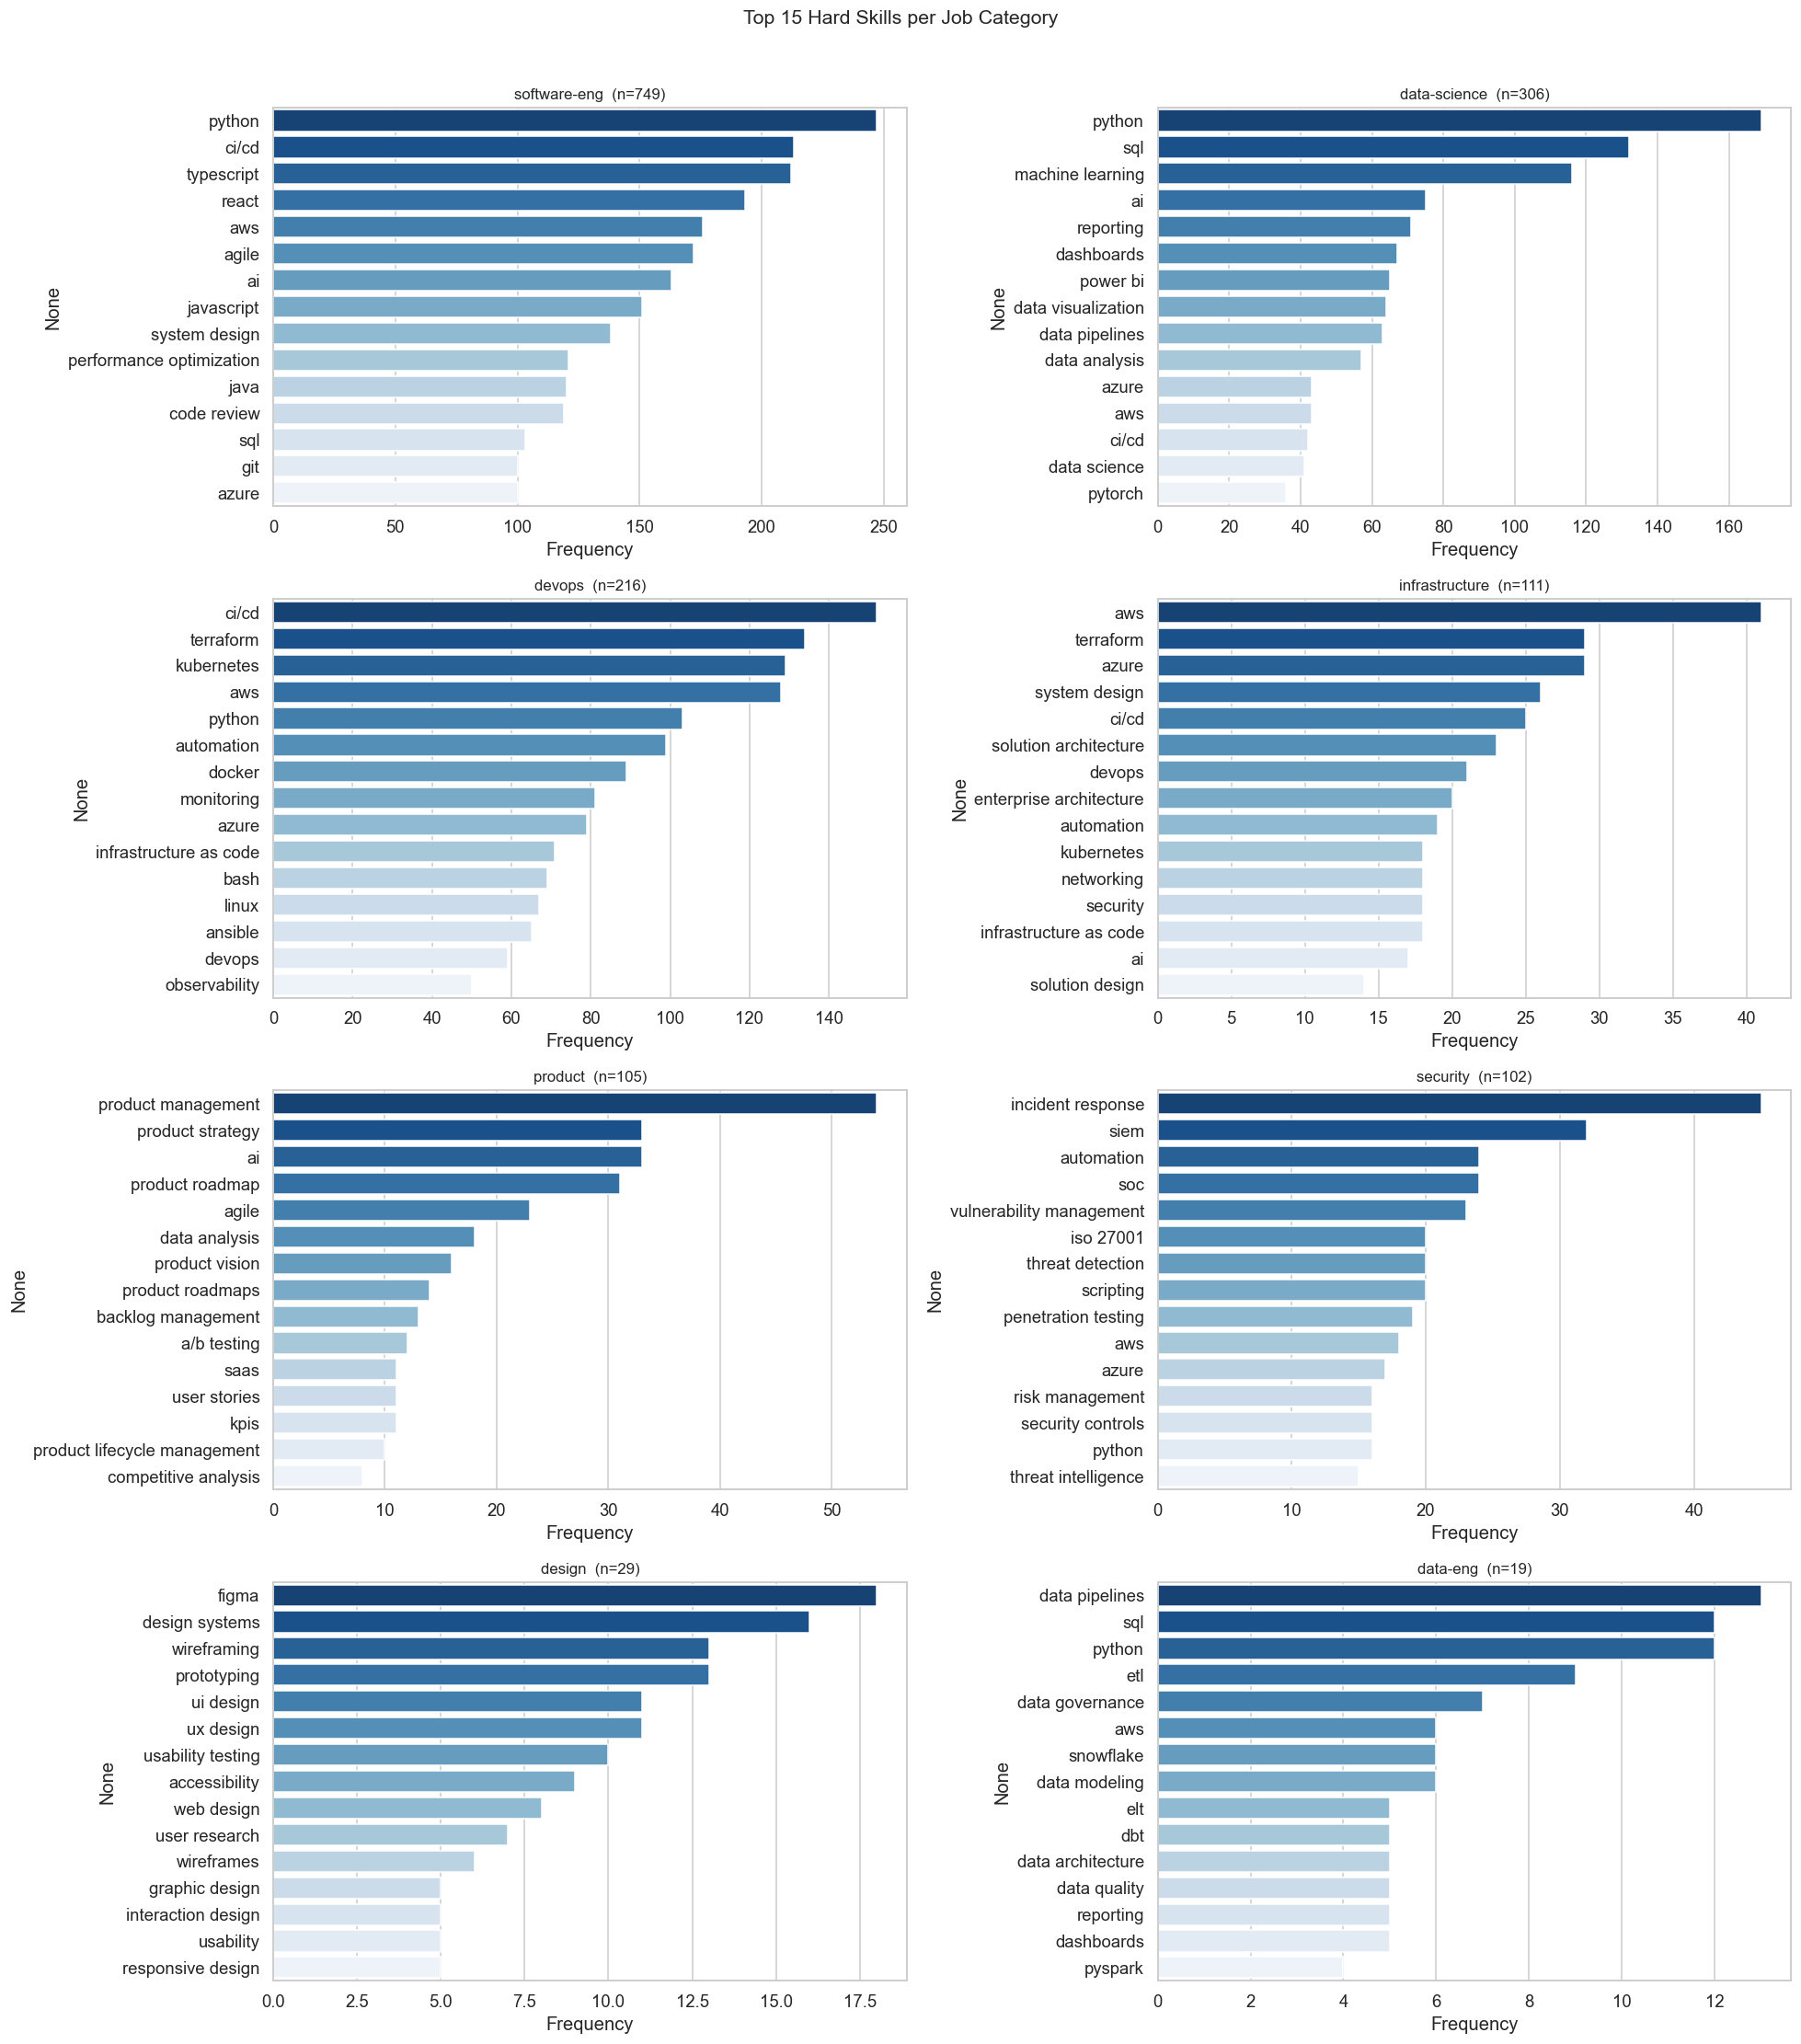

In [8]:
categories = df['job_category'].value_counts().index.tolist()
n_cols = 2
n_rows = -(-len(categories) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[df['job_category'] == cat]
    top = top_n(sub['hard_skills'], n=15)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='Blues_r')
    axes[i].set_title(f'{cat}  (n={len(sub):,})', fontsize=11)
    axes[i].set_xlabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 15 Hard Skills per Job Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Most In-Demand & Most Essential Skills

**Essential score** = `frequency x n_categories`

In [9]:
total_cnt = Counter(parse_skills(df['hard_skills']))
n_cats = df['job_category'].nunique()

skill_cat_sets = {}
for _, row in df[df['hard_skills'].notna()].iterrows():
    for sk in str(row['hard_skills']).split(','):
        sk = sk.strip().lower()
        if sk:
            skill_cat_sets.setdefault(sk, set()).add(row['job_category'])

rows_data = []
for sk, cnt in total_cnt.items():
    n_cat = len(skill_cat_sets.get(sk, set()))
    rows_data.append({'skill': sk, 'frequency': cnt, 'n_categories': n_cat,
                      'coverage_pct': round(cnt / len(df) * 100, 1),
                      'essential_score': cnt * n_cat})

skill_df = pd.DataFrame(rows_data).sort_values('essential_score', ascending=False)
top_ess = skill_df[skill_df['frequency'] >= 5].head(20)

print(f'Total unique hard skills: {len(skill_df):,}')
print()
print('Top 20 Most Essential Skills:')
print(top_ess[['skill', 'frequency', 'n_categories', 'coverage_pct', 'essential_score']].to_string(index=False))

Total unique hard skills: 5,924

Top 20 Most Essential Skills:
           skill  frequency  n_categories  coverage_pct  essential_score
          python        561             7          34.3             3927
             aws        414             7          25.3             2898
           ci/cd        442             6          27.0             2652
              ai        323             8          19.7             2584
           agile        275             8          16.8             2200
             sql        264             7          16.1             1848
           azure        272             6          16.6             1632
   system design        224             7          13.7             1568
      automation        212             7          13.0             1484
      kubernetes        239             6          14.6             1434
      typescript        228             6          13.9             1368
       terraform        211             6          12.9      

In [10]:
top_ess25 = skill_df[skill_df['frequency'] >= 5].head(25).sort_values('essential_score', ascending=True)
top_broad = skill_df[skill_df['frequency'] >= 10].nlargest(20, 'n_categories').sort_values('n_categories', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

sns.barplot(x='essential_score', y='skill', data=top_ess25, ax=axes[0],
            palette='viridis', hue='skill', legend=False)
axes[0].set_title('Top 25 Most Essential Hard Skills (Score = Frequency x Categories)', fontsize=12)
axes[0].set_xlabel('Essential Score')
axes[0].set_ylabel('')
for p in axes[0].patches:
    axes[0].text(p.get_width() + 1, p.get_y() + p.get_height()/2,
                 f'{int(p.get_width())}', va='center', fontsize=8)

sns.barplot(x='n_categories', y='skill', data=top_broad, ax=axes[1],
            palette='Blues_r', hue='skill', legend=False)
axes[1].set_title('Skills Spanning Most Job Categories (Cross-industry Breadth)', fontsize=12)
axes[1].set_xlabel('Number of Job Categories')
axes[1].set_ylabel('')
axes[1].axvline(n_cats, color='red', lw=1.5, ls='--', alpha=0.7, label=f'Max ({n_cats})')
axes[1].legend(fontsize=9)
for p in axes[1].patches:
    axes[1].text(p.get_width() + 0.05, p.get_y() + p.get_height()/2,
                 f'{int(p.get_width())}', va='center', fontsize=8)

plt.suptitle('Skill Demand Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 8) (1149058689.py, line 8)

---
## 5. Hard Skills by Seniority Level

In [ ]:
levels = [l for l in ['junior', 'mid', 'senior', 'lead'] if (df['seniority'] == l).sum() > 10]
n_l = len(levels)

fig, axes = plt.subplots(1, n_l, figsize=(5 * n_l, 7))
if n_l == 1: axes = [axes]

for i, level in enumerate(levels):
    sub = df[df['seniority'] == level]
    top = top_n(sub['hard_skills'], n=12)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='Blues_r')
    axes[i].set_title(f'{level.title()}  (n={len(sub):,})')
    axes[i].set_xlabel('Frequency')
    if i > 0: axes[i].set_ylabel('')

plt.suptitle('Top Hard Skills by Seniority Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
n_j = (df['seniority'] == 'junior').sum()
n_s = (df['seniority'] == 'senior').sum()

if n_j > 10 and n_s > 10:
    c_j = Counter(parse_skills(df[df['seniority'] == 'junior']['hard_skills']))
    c_s = Counter(parse_skills(df[df['seniority'] == 'senior']['hard_skills']))

    diffs = {}
    for sk in set(c_j) | set(c_s):
        j_pct = c_j.get(sk, 0) / n_j
        s_pct = c_s.get(sk, 0) / n_s
        if j_pct + s_pct >= 0.02:
            diffs[sk] = s_pct - j_pct

    senior_lean = sorted(diffs.items(), key=lambda x: -x[1])[:15]
    junior_lean = sorted(diffs.items(), key=lambda x:  x[1])[:15]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sk, vals = zip(*senior_lean)
    sns.barplot(x=list(vals), y=list(sk), ax=axes[0], palette='Blues_r')
    axes[0].set_title('Skills skewing toward Senior')
    axes[0].set_xlabel('Delta% (senior - junior)')
    axes[0].axvline(0, color='gray', lw=0.8, ls='--')

    sk, vals = zip(*junior_lean)
    sns.barplot(x=list(vals), y=list(sk), ax=axes[1], palette='Oranges_r')
    axes[1].set_title('Skills skewing toward Junior')
    axes[1].set_xlabel('Delta% (senior - junior)')
    axes[1].axvline(0, color='gray', lw=0.8, ls='--')

    plt.suptitle('Hard Skills — Senior vs Junior Differentiation', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f'Not enough data: junior={n_j}, senior={n_s}')

---
## 6. Soft Skills Analysis

In [ ]:
soft_top25 = top_n(df['soft_skills'], n=25)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=soft_top25.values, y=soft_top25.index, ax=ax, palette='Oranges_r')
ax.set_title('Top 25 Soft Skills — All Categories', fontsize=13)
ax.set_xlabel('Number of job postings')
for p, v in zip(ax.patches, soft_top25.values):
    ax.text(p.get_width() + 1, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 25 Soft Skills:')
for skill, cnt in soft_top25.items():
    print(f'  {skill:<35} {cnt:>4}  ({cnt/len(df)*100:.1f}%)')

In [ ]:
categories = df['job_category'].value_counts().index.tolist()
n_cols = 2
n_rows = -(-len(categories) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[df['job_category'] == cat]
    top = top_n(sub['soft_skills'], n=10)
    if len(top) == 0:
        axes[i].set_visible(False)
        continue
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='Oranges_r')
    axes[i].set_title(f'{cat}  (n={len(sub):,})', fontsize=11)
    axes[i].set_xlabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Soft Skills per Job Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Category Signature Skills

Skills where >=55% of all appearances are in one category.

In [ ]:
total_hard = Counter(parse_skills(df['hard_skills']))
cat_cnt = {cat: Counter(parse_skills(df[df['job_category'] == cat]['hard_skills']))
           for cat in df['job_category'].unique()}

signature = {}
for cat, counter in cat_cnt.items():
    sigs = []
    for sk, cnt in counter.items():
        total = total_hard[sk]
        if total >= 5 and cnt / total >= 0.55:
            sigs.append({'skill': sk, 'count': cnt, 'pct': round(cnt / total * 100)})
    signature[cat] = sorted(sigs, key=lambda x: -x['count'])[:12]

print('=== Signature Skills per Category (>=55% concentration) ===')
for cat, sigs in signature.items():
    if sigs:
        print(f'{cat}:')
        for s in sigs[:8]:
            print(f'  {s["skill"]:<40} {s["count"]:>3} postings  ({s["pct"]}% in this cat)')
        print()

In [ ]:
cats_with_sigs = {cat: sigs for cat, sigs in signature.items() if sigs}
n_cols = 2
n_rows = -(-len(cats_with_sigs) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, (cat, sigs) in enumerate(cats_with_sigs.items()):
    labels = [s['skill'] for s in sigs[:10]]
    values = [s['count'] for s in sigs[:10]]
    sns.barplot(x=values, y=labels, ax=axes[i], palette='Purples_r')
    axes[i].set_title(f'Signature skills — {cat}')
    axes[i].set_xlabel('Count in this category')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Category-Defining Hard Skills  (>=55% of appearances in one category)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Skills Co-occurrence Heatmap

In [ ]:
top25_skills = [k for k, _ in Counter(parse_skills(df['hard_skills'])).most_common(25)]
n = len(top25_skills)
cooc = np.zeros((n, n), dtype=int)

for cell in df['hard_skills'].dropna():
    row_sk = {s.strip().lower() for s in str(cell).split(',') if s.strip()}
    idxs   = [i for i, sk in enumerate(top25_skills) if sk in row_sk]
    for a_i in idxs:
        for b_i in idxs:
            if a_i != b_i:
                cooc[a_i][b_i] += 1

cooc_df = pd.DataFrame(cooc, index=top25_skills, columns=top25_skills)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.eye(n, dtype=bool)
sns.heatmap(cooc_df, mask=mask, cmap='YlOrRd', ax=ax,
            linewidths=0.3, annot=True, fmt='d', annot_kws={'size': 6},
            cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Hard Skills Co-occurrence — Top 25', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

---
## 9. Location & Remote Trends

In [ ]:
loc = df['location'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=loc.values, y=loc.index, ax=ax, palette='muted')
ax.set_title('Top 20 Hiring Locations')
ax.set_xlabel('Count')
for p, v in zip(ax.patches, loc.values):
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height()/2, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
remote_cat = df.groupby(['job_category', 'remote_status']).size().unstack(fill_value=0)
remote_pct = remote_cat.div(remote_cat.sum(axis=1), axis=0) * 100

ax = remote_pct.plot(kind='bar', stacked=True, figsize=(13, 5), colormap='Set2', width=0.7)
ax.set_title('Remote Status by Job Category (%)')
ax.set_ylabel('% of postings')
ax.set_xlabel('')
ax.legend(title='Remote', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Remote % by category:')
print(remote_pct.round(1).to_string())

In [ ]:
remote_df = df[df['remote_status'] == 'remote']
onsite_df = df[df['remote_status'] == 'onsite']
n_r, n_o  = len(remote_df), len(onsite_df)
print(f'Remote: {n_r}  |  Onsite: {n_o}')

if n_r > 10 and n_o > 10:
    c_r = Counter(parse_skills(remote_df['hard_skills']))
    c_o = Counter(parse_skills(onsite_df['hard_skills']))
    diff = {}
    for sk in set(c_r) | set(c_o):
        r_p = c_r.get(sk, 0) / n_r
        o_p = c_o.get(sk, 0) / n_o
        if r_p + o_p >= 0.02:
            diff[sk] = r_p - o_p

    r_lean = sorted(diff.items(), key=lambda x: -x[1])[:12]
    o_lean = sorted(diff.items(), key=lambda x:  x[1])[:12]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sk, vals = zip(*r_lean)
    sns.barplot(x=list(vals), y=list(sk), ax=axes[0], palette='Blues_r')
    axes[0].set_title('Skills more common in Remote roles')
    axes[0].set_xlabel('Delta% (remote - onsite)')

    sk, vals = zip(*o_lean)
    sns.barplot(x=list(vals), y=list(sk), ax=axes[1], palette='Reds_r')
    axes[1].set_title('Skills more common in Onsite roles')
    axes[1].set_xlabel('Delta% (remote - onsite)')

    plt.suptitle('Remote vs Onsite — Skill Preferences', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough remote/onsite data for comparison')